In [1]:
%env PYTORCH_ENABLE_MPS_FALLBACK=1

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
import lightning as L
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from torch.utils.data import DataLoader, random_split
import torch
import sys
sys.path.append("..")
from src.utils import MoonsDataset
from src.models import MarginalDensityFlow
from functools import partial
from src.criticism import c2st, z_test
from src.data.toy_models import NormalNormal
from src.data.sir_model import SIRModel, SIModel, SIRSModel
from src.data.seir_model import SEIRModel
from scipy.special import logit
from scipy.stats import kstest

mps_device = torch.device("mps")

env: PYTORCH_ENABLE_MPS_FALLBACK=1


In [3]:
N = 200 # 2000
noise = {"distr": "normal", "scale":1}
a = int(N * 0.8)
b = N - a

In [3]:
p_values = dict()
marginal_log_likelihoods = dict()
models = ('sir', 'constant_hazards', 'si', 'sirs', 'seir')

In [4]:
# jeffreys bayes factor buckets
logK = [np.log(K) for K in [1, 10**0.5, 10, 10**1.5, 100]]
evidence = ["Negligible", "Substantial", "Strong", "Very Strong", "Decisive"]
jeffreys = list(zip(evidence, logK))

In [5]:
def bayes_factors(m1, m2):
    print(f"Evidence in Favor of {m1} over {m2}:")
    bf = marginal_log_likelihoods[m1] - marginal_log_likelihoods[m2]
    # p = (bf <= 0).mean()
    # print(f"Negative: {p: .3f}")
    for e, logK in jeffreys:
        p = (bf > logK).mean()
        print(f"{e}: {p:.3f}")

In [6]:
def z_test(model, alpha = 0.05):
    print(f"Proportion of misspecification for model {model} at confidence level {alpha}:")
    print((p_values[model] <= alpha).mean())

# SIR Model

In [7]:
sir_dataset = SIRModel(beta=1.5, gamma=.5, prior_scale=[1, 1], N=100, T=10, observed_seed=9, n_sample=N,
                  mode="criticism", noise=noise)
sir_dataset.sample_model()
train_data, val_data = random_split(sir_dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=200)
val_loader = DataLoader(val_data, batch_size=b)

Simulating samples...


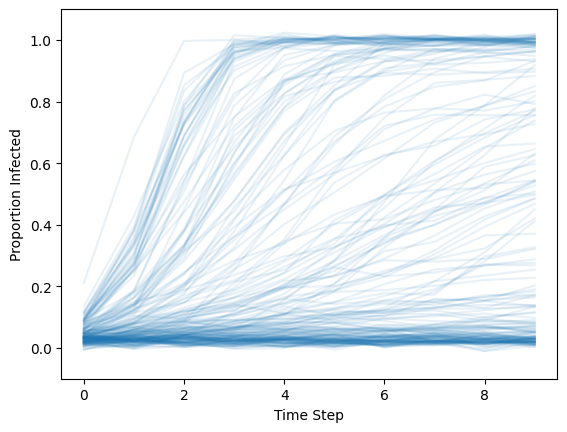

In [8]:
x_sample = sir_dataset.data[:200].squeeze(1).T
plt.plot(x_sample, alpha=0.1, color="tab:blue")
plt.ylim(-0.1, 1.1)
plt.xlabel("Time Step")
plt.ylabel("Proportion Infected")
plt.savefig("figures/sir-marginal.png")
plt.show()

In [10]:
optim = partial(torch.optim.AdamW, lr=0.0005)
model = MarginalDensityFlow(10, 5, flow_type="MAF", optimizer=optim)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name | Type | Params | Mode 
--------------------------------------
0 | flow | MAF  | 30.8 K | train
--------------------------------------
30.8 K    Trainable params
0         Non-trainable params
30.8 K    Total params
0.123     Total estimated model params size (MB)
39        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                  | 0/? [00:00<?, ?it/s]

Training: |                                                         | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

...

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

In [11]:
x_val, mll_val = trainer.predict(model, val_loader)[0]
samples = model.sample(x_val.shape[0])
c2st(x_val.squeeze(1), samples)

Predicting: |                                                       | 0/? [00:00<?, ?it/s]

tensor(0.5575, dtype=torch.float64)

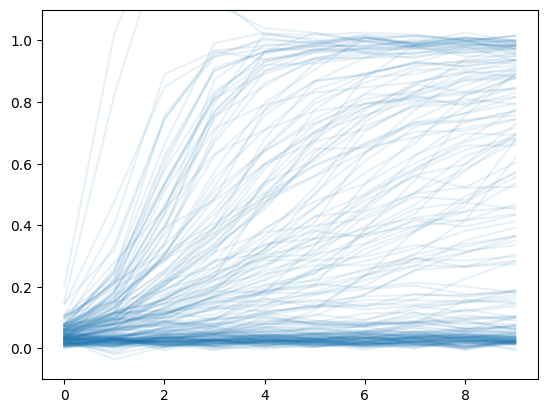

In [12]:
plt.plot(samples[:200, :].T, alpha=0.1, color="tab:blue")
plt.ylim(-0.1, 1.1)
plt.show()

## Generating "True" Data

In [12]:
s = 0
x_observed = []
A = []
B = []
while s < 1000:
    theta = sir_dataset.sample_prior(1, s)[0]
    x = sir_dataset.simulate(theta, s)
    x_observed.append(x)
    _, log_prob = model.predict_step(x)
    log_prob = log_prob.detach().item()
    A.append(log_prob)
    p_value = (log_prob > mll_val).float().mean()
    B.append(p_value)
    s += 1
marginal_log_likelihoods["sir"] = np.array(A)
p_values["sir"] = np.array(B)

In [13]:
z_test("sir")

Proportion of misspecification for model sir at confidence level 0.05:
0.038


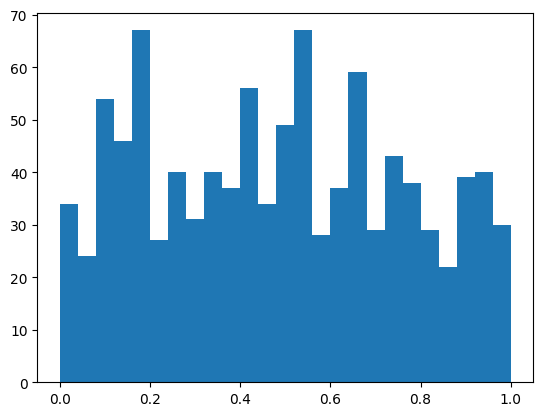

In [72]:
plt.hist(p_values["sir"], bins=25)
plt.show()

In [14]:
kstest(p_values["sir"], cdf="uniform")
# on the contrary, the p-values aren't quite uniform

KstestResult(statistic=np.float64(0.053999988079071026), pvalue=np.float64(0.005642848474097588), statistic_location=np.float32(0.675), statistic_sign=np.int8(1))

# SIR Constant Hazards

In [10]:
ch_dataset = SIRModel(beta=1.5, gamma=.5, prior_scale=[1, 1], N=100, T=10, observed_seed=9, n_sample=N,
                  mode="criticism", noise=noise, constant_hazard=7)
ch_dataset.sample_model()
train_data, val_data = random_split(ch_dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=200)
val_loader = DataLoader(val_data, batch_size=b)

Simulating samples...


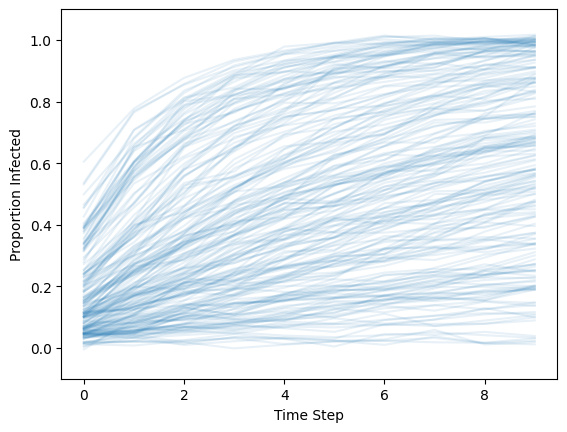

In [11]:
x_sample = ch_dataset.data[:200].squeeze(1).T
plt.plot(x_sample, alpha=0.1, color="tab:blue")
plt.ylim(-0.1, 1.1)
plt.xlabel("Time Step")
plt.ylabel("Proportion Infected")
plt.savefig("figures/ch-marginal.png")
plt.show()

In [16]:
# x_sample = ch_dataset.data[:200].squeeze(1).T
# plt.plot(x_sample, alpha=0.1, color="tab:blue")
# plt.ylim(-0.1, 1.1)
# plt.show()

In [17]:
optim = partial(torch.optim.AdamW, lr=0.0005)
model = MarginalDensityFlow(10, 5, flow_type="MAF", optimizer=optim)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | embed | Identity | 0      | train
1 | flow  | MAF      | 30.8 K | train
-------------------------------------------
30.8 K    Trainable params
0         Non-trainable params
30.8 K    Total params
0.123     Total estimated model params size (MB)
40        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                        | 0/? [00:00<?, ?it/s]

Training: |                                               | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

...

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

In [18]:
x_val, mll_val = trainer.predict(model, val_loader)[0]
samples = model.sample(x_val.shape[0])
c2st(x_val.squeeze(1), samples)

Predicting: |                                             | 0/? [00:00<?, ?it/s]

tensor(0.5538, dtype=torch.float64)

In [19]:
A = []
B = []
for x in x_observed:
    _, log_prob = model.predict_step(x)
    log_prob = log_prob.detach().item()
    A.append(log_prob)
    p_value = (log_prob > mll_val).float().mean()
    B.append(p_value)
marginal_log_likelihoods["constant_hazards"] = np.array(A)
p_values["constant_hazards"] = np.array(B)

In [20]:
z_test("constant_hazards")
# remember: for half of all SIR trajectories, beta < gamma so there's no outbreak
# should be hard to distinguish, no?
# plt.hist(p_values)
# plt.show()

bayes_factors("sir", "constant_hazards")

Proportion of misspecification for model constant_hazards at confidence level 0.05:
0.433
Evidence in Favor of sir over constant_hazards:
Negligible: 0.906
Substantial: 0.864
Strong: 0.784
Very Strong: 0.644
Decisive: 0.490


# SI Model

In [12]:
si_dataset = SIModel(beta=1.5, prior_scale=[1,], N=100, T=10, observed_seed=9, n_sample=N,
                  mode="criticism", noise=noise)
si_dataset.sample_model()
train_data, val_data = random_split(ch_dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=200)
val_loader = DataLoader(val_data, batch_size=b)

Simulating samples...


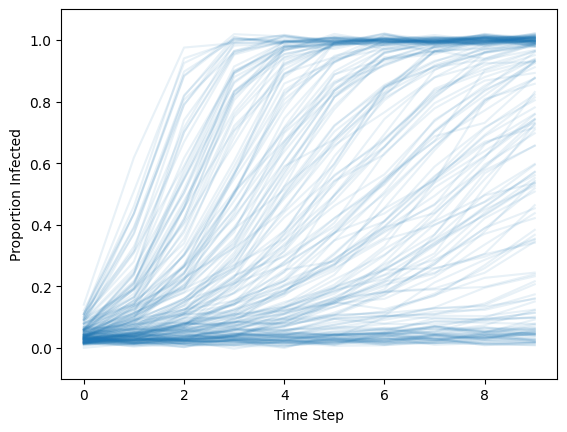

In [13]:
x_sample = si_dataset.data[:200].squeeze(1).T
plt.plot(x_sample, alpha=0.1, color="tab:blue")
plt.ylim(-0.1, 1.1)
plt.xlabel("Time Step")
plt.ylabel("Proportion Infected")
plt.savefig("figures/si-marginal.png")
plt.show()

In [22]:
# x_sample = si_dataset.data[:200].squeeze(1).T
# plt.plot(x_sample, alpha=0.1, color="tab:blue")
# plt.ylim(-0.1, 1.1)
# plt.show()

In [23]:
optim = partial(torch.optim.AdamW, lr=0.0005)
model = MarginalDensityFlow(10, 5, flow_type="MAF", optimizer=optim)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | embed | Identity | 0      | train
1 | flow  | MAF      | 30.8 K | train
-------------------------------------------
30.8 K    Trainable params
0         Non-trainable params
30.8 K    Total params
0.123     Total estimated model params size (MB)
40        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                        | 0/? [00:00<?, ?it/s]

Training: |                                               | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

...

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

In [24]:
x_val, mll_val = trainer.predict(model, val_loader)[0]
samples = model.sample(x_val.shape[0])
c2st(x_val.squeeze(1), samples)

Predicting: |                                             | 0/? [00:00<?, ?it/s]

tensor(0.5363, dtype=torch.float64)

In [25]:
A = []
B = []
for x in x_observed:
    _, log_prob = model.predict_step(x)
    log_prob = log_prob.detach().item()
    A.append(log_prob)
    p_value = (log_prob > mll_val).float().mean()
    B.append(p_value)
marginal_log_likelihoods["si"] = np.array(A)
p_values["si"] = np.array(B)

In [26]:
z_test("si")

bayes_factors("sir", "si")

Proportion of misspecification for model si at confidence level 0.05:
0.429
Evidence in Favor of sir over si:
Negligible: 0.906
Substantial: 0.855
Strong: 0.781
Very Strong: 0.656
Decisive: 0.502


# SIRS Model

In [15]:
sirs_dataset = SIRSModel(beta=1.5, gamma=1, delta=0.5, prior_scale=[1,1, 1], N=100, T=10, observed_seed=9, n_sample=N,
                  mode="criticism", noise=noise)
sirs_dataset.sample_model()
train_data, val_data = random_split(sirs_dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=200)
val_loader = DataLoader(val_data, batch_size=b)

Simulating samples...


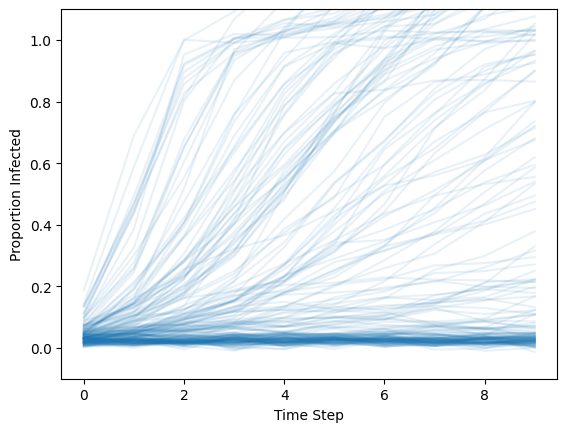

In [21]:
x_sample = sirs_dataset.data[:200].squeeze(1).T
plt.plot(x_sample, alpha=0.1, color="tab:blue")
plt.ylim(-0.1, 1.1)
plt.xlabel("Time Step")
plt.ylabel("Proportion Infected")
plt.savefig("figures/sirs-marginal.png")
plt.show()

In [28]:
optim = partial(torch.optim.AdamW, lr=0.0005)
model = MarginalDensityFlow(10, 5, flow_type="MAF", optimizer=optim)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | embed | Identity | 0      | train
1 | flow  | MAF      | 30.8 K | train
-------------------------------------------
30.8 K    Trainable params
0         Non-trainable params
30.8 K    Total params
0.123     Total estimated model params size (MB)
40        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                        | 0/? [00:00<?, ?it/s]

Training: |                                               | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

...

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

In [29]:
x_val, mll_val = trainer.predict(model, val_loader)[0]
samples = model.sample(x_val.shape[0])
c2st(x_val.squeeze(1), samples)

Predicting: |                                             | 0/? [00:00<?, ?it/s]

tensor(0.5988, dtype=torch.float64)

In [31]:
A = []
B = []
for x in x_observed:
    _, log_prob = model.predict_step(x)
    log_prob = log_prob.detach().item()
    A.append(log_prob)
    p_value = (log_prob > mll_val).float().mean()
    B.append(p_value)
marginal_log_likelihoods["sirs"] = np.array(A)
p_values["sirs"] = np.array(B)

In [32]:
z_test("sirs")

bayes_factors("sir", "sirs")

Proportion of misspecification for model sirs at confidence level 0.05:
0.048
Evidence in Favor of sir over sirs:
Negligible: 0.693
Substantial: 0.408
Strong: 0.266
Very Strong: 0.199
Decisive: 0.149


# SEIR Model

In [4]:
seir_dataset = SEIRModel(beta=1.5, gamma=0.5, sigma=1, prior_scale=[1,1, 1], N=100, T=10, observed_seed=9, n_sample=N,
                  mode="criticism", noise=noise)
seir_dataset.sample_model()
train_data, val_data = random_split(seir_dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=200)
val_loader = DataLoader(val_data, batch_size=b)

Simulating samples...


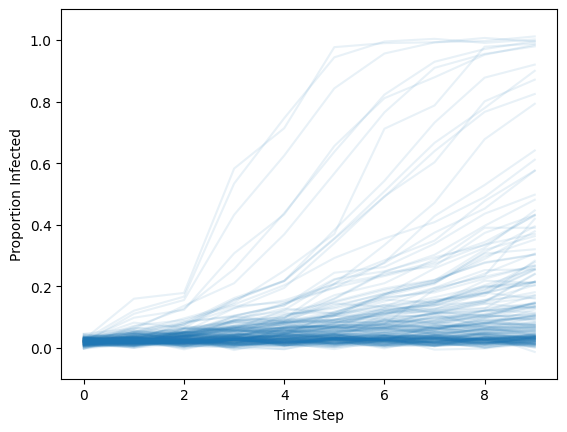

In [5]:
x_sample = seir_dataset.data[:200].squeeze(1).T
plt.plot(x_sample, alpha=0.1, color="tab:blue")
plt.ylim(-0.1, 1.1)
plt.xlabel("Time Step")
plt.ylabel("Proportion Infected")
plt.savefig("figures/seir-marginal.png")
plt.show()

In [34]:
# x_sample = seir_dataset.data[:200].squeeze(1).T
# plt.plot(x_sample, alpha=0.1, color="tab:blue")
# plt.ylim(-0.1, 1.1)
# plt.show()

In [35]:
optim = partial(torch.optim.AdamW, lr=0.0005)
model = MarginalDensityFlow(10, 5, flow_type="MAF", optimizer=optim)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | embed | Identity | 0      | train
1 | flow  | MAF      | 30.8 K | train
-------------------------------------------
30.8 K    Trainable params
0         Non-trainable params
30.8 K    Total params
0.123     Total estimated model params size (MB)
40        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                        | 0/? [00:00<?, ?it/s]

Training: |                                               | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

...

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

In [36]:
x_val, mll_val = trainer.predict(model, val_loader)[0]
samples = model.sample(x_val.shape[0])
c2st(x_val.squeeze(1), samples)

Predicting: |                                             | 0/? [00:00<?, ?it/s]

tensor(0.5188, dtype=torch.float64)

In [37]:
A = []
B = []
for x in x_observed:
    _, log_prob = model.predict_step(x)
    log_prob = log_prob.detach().item()
    A.append(log_prob)
    p_value = (log_prob > mll_val).float().mean()
    B.append(p_value)
marginal_log_likelihoods["seir"] = np.array(A)
p_values["seir"] = np.array(B)

In [38]:
z_test("seir")

bayes_factors("sir", "seir")

Proportion of misspecification for model seir at confidence level 0.05:
0.399
Evidence in Favor of sir over seir:
Negligible: 0.699
Substantial: 0.534
Strong: 0.461
Very Strong: 0.404
Decisive: 0.365


# Write Out Results

In [41]:
# marginal_log_likelihoods = pd.read_csv("results/marginal_log_likelihoods.csv", index_col=0).to_dict()
# p_values = pd.read_csv("results/p_values.csv", index_col=0).to_dict()

df_pv = pd.DataFrame(p_values)
df_mll = pd.DataFrame(marginal_log_likelihoods)


In [44]:
df_pv.to_csv("results/p_values.csv")
df_mll.to_csv("results/marginal_log_likelihoods.csv")

# Table for Hypothesis Testing

In [57]:
(df_pv < 0.10).mean(0)

sir                 0.076
constant_hazards    0.446
si                  0.443
sirs                0.096
seir                0.439
dtype: float64

In [54]:
(df_pv < 0.05).mean(0)

sir                 0.037
constant_hazards    0.432
si                  0.429
sirs                0.045
seir                0.391
dtype: float64

In [56]:
(df_pv < 0.025).mean(0)

sir                 0.022
constant_hazards    0.421
si                  0.419
sirs                0.012
seir                0.359
dtype: float64

# Visualizing Bayes Factors

In [103]:
# a grouped bar plot where the bars indicate the number of datasets falling into each evidence group

In [ ]:
# def bayes_factors_plotter
# dataframe w/ columns: comparison (e.g. M1 vs M2), count, and evidence level

In [39]:
comparisons = [(0, i) for i in range(1, len(models))]
comparisons

[(0, 1), (0, 2), (0, 3), (0, 4)]

In [42]:
df_plot = {"Comparison": [], "Trials": [], "Evidence": []}
for a,b in comparisons:
    m1 = models[a]
    m2 = models[b]
    tag = f"$B_{{{a},{b}}}$"
    bf = df_mll[m1] - df_mll[m2]
    for i in range(len(jeffreys) - 1):
        t = ((bf > jeffreys[i][1]) & (bf <= jeffreys[i+1][1])).sum()
        df_plot["Comparison"].append(tag)
        df_plot["Trials"].append(t)
        df_plot["Evidence"].append(jeffreys[i][0])
    t = (bf > jeffreys[-1][1]).sum()
    df_plot["Comparison"].append(tag)
    df_plot["Trials"].append(t)
    df_plot["Evidence"].append(jeffreys[-1][0])
df_plot = pd.DataFrame(df_plot)

In [147]:
df_plot

,Comparison,Trials,Evidence
0,"$B_{0,1}$",47,Negligible
1,"$B_{0,1}$",82,Substantial
2,"$B_{0,1}$",152,Strong
3,"$B_{0,1}$",149,Very Strong
4,"$B_{0,1}$",465,Decisive
5,"$B_{0,2}$",55,Negligible
6,"$B_{0,2}$",81,Substantial
7,"$B_{0,2}$",152,Strong
8,"$B_{0,2}$",149,Very Strong
9,"$B_{0,2}$",455,Decisive


In [73]:
df_plot.groupby("Comparison")["Trials"].sum()

Comparison
$B_{0,1}$    906
$B_{0,2}$    906
$B_{0,3}$    693
$B_{0,4}$    699
Name: Trials, dtype: int64

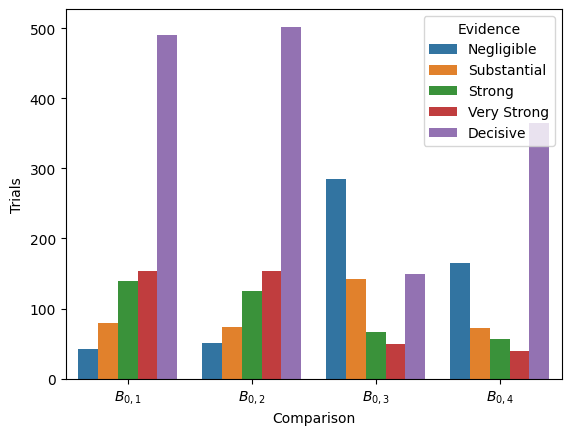

In [45]:
sns.barplot(df_plot, x="Comparison", y="Trials", hue="Evidence")
plt.savefig("figures/bayes_factors.png")
plt.show()